In [53]:
import pandas as pd
import seaborn as sns
import numpy as np
import re
from sklearn.model_selection import train_test_split


In [54]:
data = pd.read_csv(r"C:/Users/Administrator/Downloads/hbaac-round2/train.csv", low_memory = False)

In [55]:
def to_snake_case(name):
    """Hàm chuyển đổi tên cột sang định dạng snake_case"""
    name = name.strip()
    # Chèn dấu gạch dưới vào trước ký tự viết hoa (xử lý dạng CamelCase)
    name = re.sub(r'(?<!^)(?=[A-Z])', '_', name)
    # Chuyển về chữ thường, thay thế khoảng trắng và dấu gạch ngang bằng dấu gạch dưới
    name = name.lower().replace(' ', '_').replace('-', '_')
    # Loại bỏ các dấu gạch dưới bị lặp liên tiếp
    while '__' in name:
        name = name.replace('__', '_')
    return name

In [56]:
data.shape

(711980, 8)

In [57]:
data.columns = [to_snake_case(col) for col in data.columns]

print("Danh sách các cột sau khi chuẩn hóa thành snake_case:")
print(data.columns.tolist())

Danh sách các cột sau khi chuẩn hóa thành snake_case:
['date', 'stt', 'item_code', 'quantity', 'unit_price', 'sales_amount', 'unit_cost', 'cost_amount']


In [58]:
# Ép kiểu về chuỗi (string) và tiến hành cắt khoảng trắng thừa ở đầu/cuối
data['stt'] = data['stt'].astype(str).str.strip()
data['item_code'] = data['item_code'].astype(str).str.strip()

print("Đã hoàn thành loại bỏ khoảng trắng thừa cho 'stt' và 'item_code'.")

Đã hoàn thành loại bỏ khoảng trắng thừa cho 'stt' và 'item_code'.


In [59]:
# Tính số dòng trùng lặp trước khi xóa
duplicate_count = data.duplicated().sum()
print(f"Số lượng dòng trùng lặp hoàn toàn phát hiện được: {duplicate_count} dòng.")

# Tiến hành loại bỏ dòng trùng lặp (chỉ giữ lại bản ghi đầu tiên)
data = data.drop_duplicates()
print(f"Kích thước dữ liệu sau khi xóa trùng lặp: {data.shape[0]} dòng.")

Số lượng dòng trùng lặp hoàn toàn phát hiện được: 1473 dòng.
Kích thước dữ liệu sau khi xóa trùng lặp: 710507 dòng.


In [60]:
# Ép kiểu dữ liệu về dạng số (Các giá trị lỗi không ép được sẽ chuyển thành NaN nhờ errors='coerce')
data['quantity'] = pd.to_numeric(data['quantity'], errors='coerce')
data['sales_amount'] = pd.to_numeric(data['sales_amount'], errors='coerce')

# Điền các giá trị trống NaN phát sinh bằng 0 (nếu có) để tránh lỗi tính toán sau này
data['quantity'] = data['quantity'].fillna(0)
data['sales_amount'] = data['sales_amount'].fillna(0)

# Kiểm tra lại kiểu dữ liệu của các cột sau khi xử lý
print(data[['quantity', 'sales_amount']].dtypes)

quantity        int64
sales_amount    int64
dtype: object


In [85]:
data.head(100)

,date,stt,item_code,quantity,unit_price,sales_amount,unit_cost,cost_amount
0,2020-11-17,2000004,SKU-08063,12,242700,2184300,"123559,1",1482709
1,2020-11-17,2000003,SKU-09458,600,"131818,1818",79090909,110000,66000000
2,2020-11-18,2000007,SKU-08062,6,230000,940909,101000,606000
3,2020-11-18,2000006,SKU-09458,240,270000,44181818,110000,26400000
4,2020-11-18,2000005,SKU-09458,240,270000,44181818,110000,26400000
...,...,...,...,...,...,...,...,...
97,2021-01-05,2000161,SKU-03349,6,"154545,4545",695455,57000,342000
98,2021-01-05,2000161,SKU-03351,40,"154545,4545",4636363,"115783,44",4631337
99,2021-01-11,2000210,SKU-08063,12,"242727,2727",2184545,"123559,1",1482709
100,2021-01-11,2000211,SKU-07771,7,"181818,1818",1094545,94000,658000


In [62]:
data.tail()

,date,stt,item_code,quantity,unit_price,sales_amount,unit_cost,cost_amount
711975,2025-09-05,1933614,SKU-11617,1,468000,468000,365924,365924
711976,2025-09-05,1933616,SKU-09360,1,470000,470000,"312747,5",312747
711977,2025-09-05,1933616,SKU-09433,2,960000,1920000,"768779,63",1537559
711978,2025-09-05,1933616,SKU-11885,2,150000,300000,"114074,07",228148
711979,2025-09-05,1933616,SKU-11835,1,1300000,1300000,1120000,1120000


In [63]:
data.describe()

,quantity,sales_amount
count,710507.000000,7.105070e+05
mean,3.435381,9.713690e+05
std,25.453463,3.890358e+06
min,-998.000000,-1.842400e+08
25%,1.000000,2.500000e+05
50%,1.000000,5.100000e+05
75%,2.000000,1.146600e+06
max,5998.000000,9.324131e+08


In [64]:
data.isnull().sum()

date            0
stt             0
item_code       0
quantity        0
unit_price      0
sales_amount    0
unit_cost       0
cost_amount     0
dtype: int64

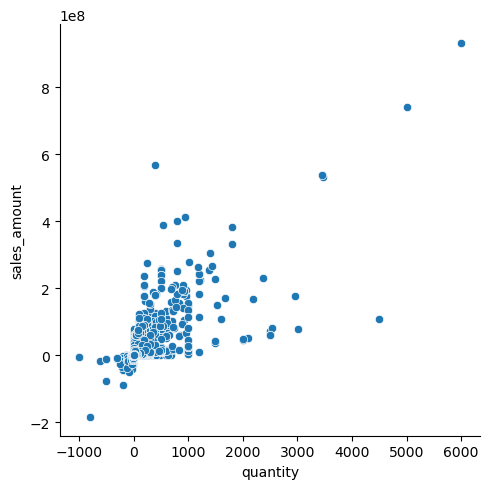

In [65]:
sns.relplot(x = 'quantity', y = 'sales_amount', data = data)

In [80]:
# Lọc ra một DataFrame riêng chỉ chứa các hàng có Quantity < 0
negative_quantity = data[data['quantity'] < 0]

# 1. In ra số lượng 
print(f"Tìm thấy {len(negative_quantity):,} giao dịch có Quantity < 0.")
print("Dưới đây là 5 dòng đầu tiên của các giao dịch này:")

# 2. Hiển thị 5 dòng đầu tiên dưới dạng bảng HTML đẹp mắt trên Jupyter
display(negative_quantity.head())

Tìm thấy 0 giao dịch có Quantity < 0.
Dưới đây là 5 dòng đầu tiên của các giao dịch này:


,date,stt,item_code,quantity,unit_price,sales_amount,unit_cost,cost_amount


In [81]:
# Lấy số lượng dòng trước khi xóa để đối chiếu
dong_truoc = len(data)

# Chỉ giữ lại các dòng có Quantity lớn hơn hoặc bằng 0
data = data[data['quantity'] >= 0]

# Tính số dòng đã bị xóa
dong_sau = len(data)
print(f"Đã loại bỏ: {dong_truoc - dong_sau:,} dòng bị âm.")
print(f"Số lượng dòng còn lại trong DataFrame: {dong_sau:,}")

Đã loại bỏ: 0 dòng bị âm.
Số lượng dòng còn lại trong DataFrame: 673,261


In [82]:
display(data.describe())

,quantity,sales_amount
count,673261.000000,6.732610e+05
mean,3.754027,1.079293e+06
std,25.942620,3.944643e+06
min,0.000000,-4.800000e+05
25%,1.000000,2.800000e+05
50%,1.000000,5.500000e+05
75%,2.000000,1.200000e+06
max,5998.000000,9.324131e+08


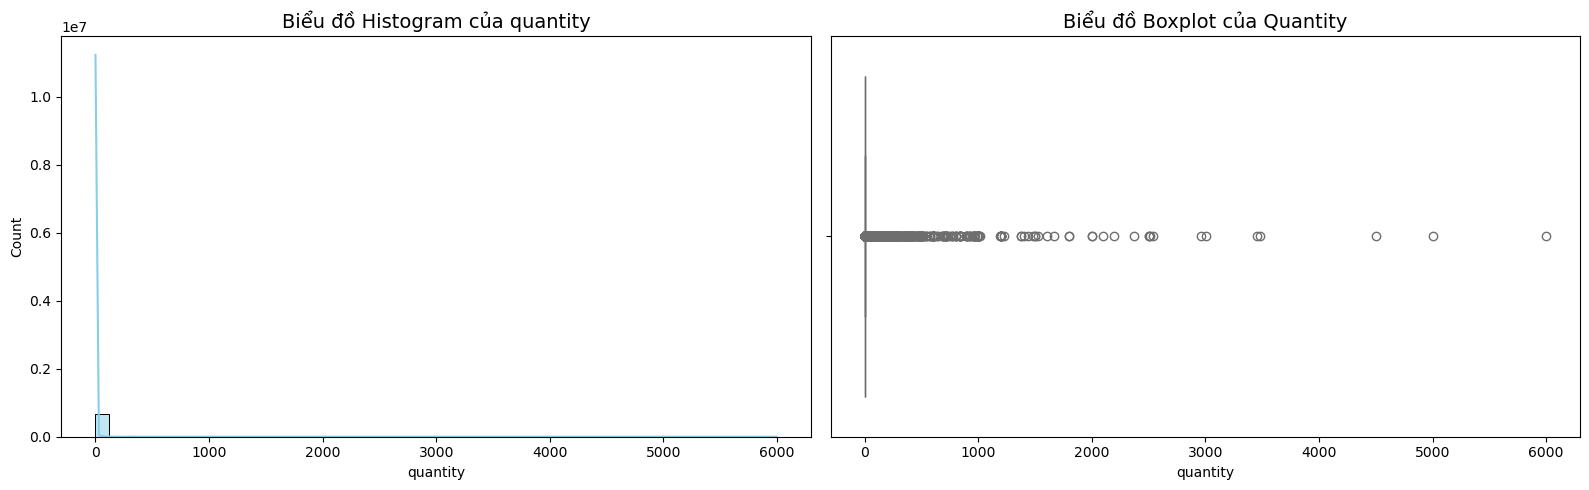

--------------------------------------------------
Giới hạn dưới (Lower Bound): -0.5
Giới hạn trên (Upper Bound): 3.5
Số lượng bản ghi outlier: 115,810
Tỷ lệ outlier trên tổng dữ liệu: 17.20%
--------------------------------------------------


In [83]:
import matplotlib.pyplot as plt
# Thiết lập khung vẽ 2 biểu đồ nằm ngang
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Vẽ Histogram
sns.histplot(data['quantity'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Biểu đồ Histogram của quantity', fontsize=14)
axes[0].set_xlabel('quantity')

# 2. Vẽ Boxplot
sns.boxplot(x=data['quantity'], ax=axes[1], color='lightcoral')
axes[1].set_title('Biểu đồ Boxplot của Quantity', fontsize=14)
axes[1].set_xlabel('quantity')

plt.tight_layout()
plt.show() # Hiển thị đồ thị trong Jupyter

# 3. Tính toán Outlier bằng Công thức IQR
Q1 = data['quantity'].quantile(0.25)
Q3 = data['quantity'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[(data['quantity'] < lower_bound) | (data['quantity'] > upper_bound)]

print("-" * 50)
print(f"Giới hạn dưới (Lower Bound): {lower_bound}")
print(f"Giới hạn trên (Upper Bound): {upper_bound}")
print(f"Số lượng bản ghi outlier: {len(outliers):,}")
print(f"Tỷ lệ outlier trên tổng dữ liệu: {len(outliers) / len(data) * 100:.2f}%")
print("-" * 50)

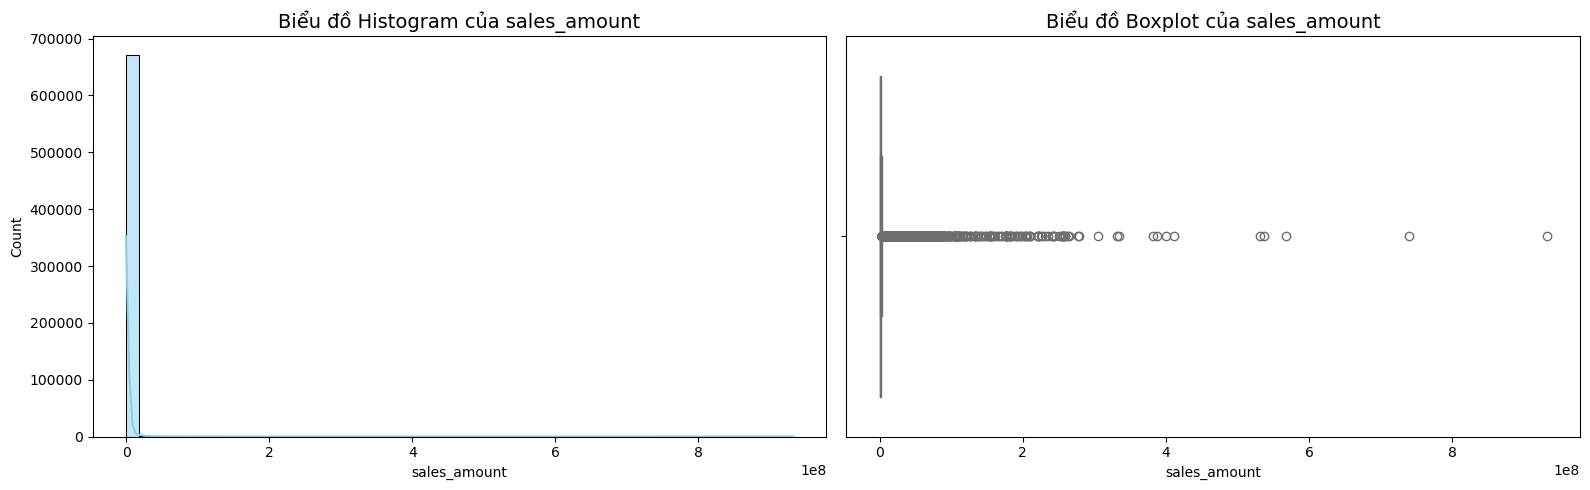

--------------------------------------------------
Giới hạn dưới (Lower Bound): -1100000.0
Giới hạn trên (Upper Bound): 2580000.0
Số lượng bản ghi outlier: 43,091
Tỷ lệ outlier trên tổng dữ liệu: 6.40%
--------------------------------------------------


In [84]:
import matplotlib.pyplot as plt
# Thiết lập khung vẽ 2 biểu đồ nằm ngang
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Vẽ Histogram
sns.histplot(data['sales_amount'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Biểu đồ Histogram của sales_amount', fontsize=14)
axes[0].set_xlabel('sales_amount')

# 2. Vẽ Boxplot
sns.boxplot(x=data['sales_amount'], ax=axes[1], color='lightcoral')
axes[1].set_title('Biểu đồ Boxplot của sales_amount', fontsize=14)
axes[1].set_xlabel('sales_amount')

plt.tight_layout()
plt.show() # Hiển thị đồ thị trong Jupyter

# 3. Tính toán Outlier bằng Công thức IQR
Q1 = data['sales_amount'].quantile(0.25)
Q3 = data['sales_amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[(data['sales_amount'] < lower_bound) | (data['sales_amount'] > upper_bound)]

print("-" * 50)
print(f"Giới hạn dưới (Lower Bound): {lower_bound}")
print(f"Giới hạn trên (Upper Bound): {upper_bound}")
print(f"Số lượng bản ghi outlier: {len(outliers):,}")
print(f"Tỷ lệ outlier trên tổng dữ liệu: {len(outliers) / len(data) * 100:.2f}%")
print("-" * 50)